# Spectral analysis of MBARI data from Elkhorn Slough 

To demonstrate how the Fourier transform can be calculated numerically to create a power spectrum, we use data from the Land Ocean Biogeochemical Observatory in Elkhorn Slough. The data come from the L01 buoy just up channel from the Highway 1 bridge. This buoy is maintained by Dr. Ken Johnson's Chemical Sensors group at MBARI, which develops new technology in order to understand high-frequency fluctuations in biogeochemical parameters over long time periods.

![LOBO Map](https://www3.mbari.org/lobo/pictures/maps/network2.jpg)

The data can be downloaded in text format at this site:
http://www3.mbari.org/lobo/getLOBOdata.htm

## Loading the data

This first "magic" command is optional. It creates interactive figures. It requires installation of the [ipympl](https://github.com/matplotlib/ipympl) package (inlcuded in the course notes for software installation).

In [1]:
%matplotlib widget

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import mlab
from scipy import stats

filename = 'data/MBARI_LOBO/L01SURF_subset.txt'
data = np.genfromtxt(filename,delimiter=',',skip_header=3)

After loading the data, missing values are replaced with NaNs and three variables are created from the larger data set: time (days since 1/1/1900), nitrate ($\mu$M) and water depth (m). These data are a small continuous subset of the multi-year time series from 1 January - 22 March 2007.

In [3]:
flagi = np.where(data>1E100)
data[flagi] = np.nan

time = data[:,1]
nitrate = data[:,2]
waterdep = data[:,3]
salinity = data[:,4]
temp = data[:,5]

## Plotting the data

First, it is always helpful to plot the data in the time domain to get a visual sense of the variability. The data set is about 80 days long. The water depth plot primarily shows the tides, which have a fortnightly spring-neap cycle. The nitrate data also show high-frequency variability due to the tides, but there are also irregular pulses of high nitate. This is the winter season, and freshwater runoff from storms can have very high nitrate concentrations because of of all the agriculture in the watershed.

In [4]:
# insert code here

#### Exercise

Plot the time series of nitrate, salinity and temperature. Discuss the factors that determine nitrate conecentrations in Elkhorn Slough? 

In [7]:
# insert code here

## Effective degrees of freedom

Is there a statistically significant linear trend in nitrate?

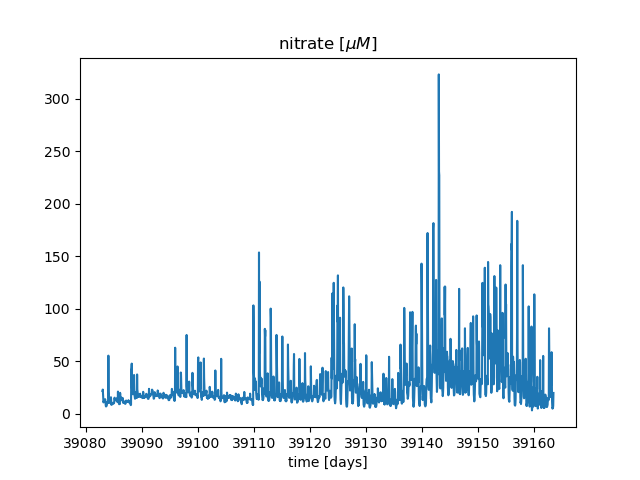

In [ ]:
plt.figure()
plt.plot(time, nitrate)
plt.xlabel('time [days]')
plt.title('nitrate [$\\mu M$]');

### Autocorrelation function and integral time scale

#### Check for significance 

Is the linear trend significant? The `rsig` function below calculates a p-value given the correlation coefficient $r$ and the degrees of freedom.

In [ ]:
def rsig(r,nu):
    """ p-value for correlation coefficient r, and degrees of freedom nu

    INPUTS:
    r - correlation coefficient
    nu - degrees of freedom (N-2)

    OUTPUT:
    p - significance level/p-value

    significance levels of 0.05 and 0.01 correspond with Appendix E in
    Emery and Thomson (2004) Data Analysis Methods in Physical
    Oceanography
    """

    # t value
    t = abs(r)*np.sqrt(nu)/np.sqrt(1-r**2)

    # significance level, using the "survival function" (1-cdf)
    p = 2*(stats.t.sf(t,nu))

    return p

p-value if using DOF = $N-2$ (too low!)

p-value if using EDOF = $N^*-2$

### Plotting the raw spectrum (or periodogram)

The course notes discuss how the periodogram can be computed from the discrete Fourier transform of the data. The signal processing library of SciPy includes a function that makes it much easier to compute the periodogram directly. It is called `periodogram`.

The `fs` argument is the sampling frequency (you can use whatever units you want as long as the value is consistent with the data. This function returns the frequency array (positive values only) and the corresponding PSD array. The values correspond exactly with those found above.

#### Exercises

* How many samples $N$ are in the time series?

* What is the sample interval $\Delta t$ in days?

* What is the fundamental frequency $f_f$ of the time series (in cycles per day)?

* What is the sampling frequency $f_s$ of the time series (in cycles per day)?

* What is the Nyquist frequency $f_N$ of the time series (in cycles per day)?

### Periodogram plot

## Exercises

* Compute the periodogram for the LOBO nitrate data. Label the y-axis with the correct units. Compare the spectrum with that of the water level spectrum. What are some similarities and differences? 

In [8]:
# insert code here

## Critique (and preview of next week)

Although we have succussfully plotted the periodogram of the data, there are two major issues with the *raw* periodogram as calculated above.

1) It is noisy (random error)

2) It is biased (systematic error)

Although this method is very useful for describing practical Fourier analysis conceptually, there are issues with it in practice. These problems led John W. Tukey (co-inventor of the FFT) to remark on the perils of using this method quantitatively:

>"More lives have been lost looking at the raw periodogram than by any other action involving time series."

Next week, we will expand on this basic method to show ways of improving on this basic method of computing the power spectrum.